In [52]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader,TensorDataset
import matplotlib.pyplot as plt

c0=torch.randn(100,2)+torch.tensor([-3.0,0.0])
c1=torch.randn(100,2)+torch.tensor([0.0,3.0])
c2=torch.randn(100,2)+torch.tensor([3.0,0.0])

x=torch.cat([c0,c1,c2],dim=0)
y=torch.cat([torch.zeros(100),torch.ones(100),torch.full((100,),2.0)]).long()

class Net(nn.Module):
  def __init__(self):
    super(Net,self).__init__()
    self.input=nn.Linear(2,32)
    self.h1=nn.Linear(32,32)
    self.h2=nn.Linear(32,32)
    self.output=nn.Linear(32,3)
    self.drop=nn.Dropout(0.3)

  def forward(self,x):
    x=torch.relu(self.input(x))
    x=self.drop(x)
    x=torch.relu(self.h1(x))
    x=self.drop(x)
    x=torch.relu(self.h2(x))
    x=self.drop(x)
    return self.output(x)

indices=torch.randperm(x.shape[0])
x=x[indices]
y=y[indices]

split=int(0.8*len(x))
x_train,x_val=x[:split],x[split:]
y_train,y_val=y[:split],y[split:]

model=Net()
optimizer=optim.Adam(model.parameters(),lr=0.001)
criterion=nn.CrossEntropyLoss()

dataset=TensorDataset(x_train,y_train)
dataloader=DataLoader(dataset,batch_size=32,shuffle=True)

train_losses=[]
val_losses=[]

best_val_loss=float('inf')
best_epoch=0

for epoch in range(500):
  model.train()
  epoch_loss=0

  for batch_x,batch_y in dataloader:
    optimizer.zero_grad()
    pred=model(batch_x)
    loss=criterion(pred,batch_y)
    loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(),max_norm=1.0)
    optimizer.step()
    epoch_loss+=loss.item()

  avg_train_loss=epoch_loss/len(dataloader)
  train_losses.append(avg_train_loss)

  model.eval()

  with torch.no_grad():
    val_pred=model(x_val)
    val_loss=criterion(val_pred,y_val).item()
    pred_class=torch.argmax(model(x_val),dim=1)
    accuracy=(pred_class==y_val).float().mean()
    val_losses.append(val_loss)

  if val_loss<best_val_loss:
    best_val_loss=val_loss
    best_epoch=epoch
    torch.save(model.state_dict(),'best_model.pt')

  if epoch % 100 == 0:
    print(f'Epoch {epoch} | Train Loss: {avg_train_loss:.6f} | Val Loss: {val_loss:.6f}')

print(f'val_loss type: {type(val_loss)}, value: {val_loss}')
model.load_state_dict(torch.load('best_model.pt'))
print(f'\nBest model at epoch {best_epoch} with val loss {best_val_loss:.6f}')

Epoch 0 | Train Loss: 1.096170 | Val Loss: 1.064707
Epoch 100 | Train Loss: 0.074813 | Val Loss: 0.067429
Epoch 200 | Train Loss: 0.046956 | Val Loss: 0.056613
Epoch 300 | Train Loss: 0.038994 | Val Loss: 0.056808
Epoch 400 | Train Loss: 0.046368 | Val Loss: 0.067856
val_loss type: <class 'float'>, value: 0.07101016491651535

Best model at epoch 270 with val loss 0.048943


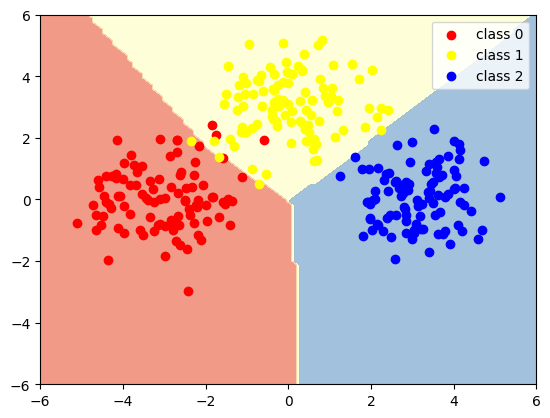

              precision    recall  f1-score   support

           0       0.95      0.95      0.95        22
           1       0.95      0.95      0.95        19
           2       1.00      1.00      1.00        19

    accuracy                           0.97        60
   macro avg       0.97      0.97      0.97        60
weighted avg       0.97      0.97      0.97        60

[[21  1  0]
 [ 1 18  0]
 [ 0  0 19]]


In [56]:
gx = torch.linspace(-6, 6, 100)
gy = torch.linspace(-6, 6, 100)
GX, GY = torch.meshgrid(gx, gy, indexing='ij')
grid = torch.stack([GX.flatten(), GY.flatten()], dim=1)

model.eval()
with torch.no_grad():
    pred = torch.argmax(model(grid), dim=1).reshape(100, 100).float()

plt.contourf(GX.numpy(), GY.numpy(), pred.numpy(), levels=[-0.5, 0.5, 1.5, 2.5], cmap='RdYlBu', alpha=0.6)
plt.scatter(c0[:,0], c0[:,1], label='class 0', c='red')
plt.scatter(c1[:,0], c1[:,1], label='class 1', c='yellow')
plt.scatter(c2[:,0], c2[:,1], label='class 2', c='blue')
plt.legend()
plt.show()

from sklearn.metrics import confusion_matrix, classification_report

model.eval()
with torch.no_grad():
    pred_class = torch.argmax(model(x_val), dim=1)

print(classification_report(y_val.numpy(), pred_class.numpy()))
print(confusion_matrix(y_val.numpy(), pred_class.numpy()))

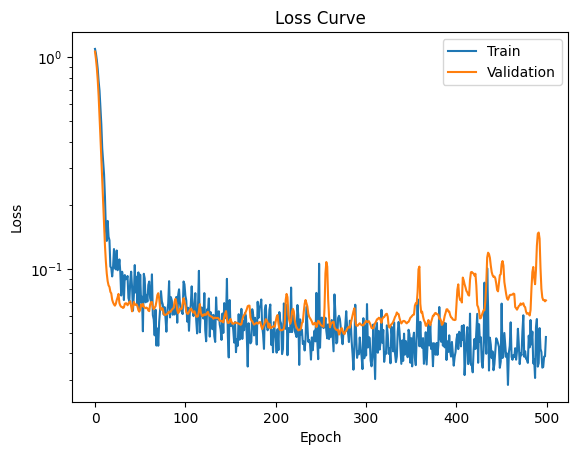

In [53]:
plt.plot(train_losses, label='Train')
plt.plot(val_losses, label='Validation')
plt.yscale('log')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('Loss Curve')
plt.show()

Observations:

1. CrossEntropyLoss replaces BCEWithLogitsLoss for 3+ classes
2. Labels must be .long() integers, shape (N,) not (N,1)
3. Output layer has one neuron per class
torch.argmax(dim=1) replaces the 0.0 threshold
4. Multi-class confusion matrix reads the same way as binary — diagonal is correct, off-diagonal is wrong